# 🩻 Foundation Models para Radiologia: ImageNet vs. Domínio Clínico
## Hands-on Vibe Coding — Sociedade Paulista de Radiologia 2026

---

### A Pergunta Central

Um modelo treinado em fotos do cotidiano (gatos, carros, 1.000 classes) tem o mesmo valor como extrator de características radiológicas que um modelo treinado em **880 mil raios-X de tórax**?

Neste hands-on você vai responder isso experimentalmente:

| Extrator | Pré-treinamento | O que aprendeu |
|---|---|---|
| **EfficientNetB0** | ImageNet (1,28M fotos naturais) | Bordas, texturas, formas gerais |
| **RAD-DINO** | 880K+ raios-X de tórax (Microsoft, 2024) | Opacidades, consolidações, textura pulmonar |

**Experimento:** congele ambos os backbones → treine a **mesma cabeça classificadora** em cada → compare o t-SNE dos embeddings e as métricas no conjunto de teste.

---

### Dataset: PneumoniaMNIST

- **1.000 imagens** de raio-X de tórax (64×64 pixels, subsample reproduzível)
- **2 classes:** Normal vs Pneumonia Bacteriana/Viral
- Download automático via `pip install medmnist` — sem login, sem cadastro
- Fonte: Kermany et al., *Cell* 2018 | Licença: CC BY 4.0

---

### Como usar este notebook

1. **Ative o GPU T4:** Menu `Ambiente de execução` → `Alterar tipo de hardware` → T4 GPU → Salvar → Reconectar
2. Para **cada Prompt Card**, copie o prompt e cole no **Gemini** (ícone ✦ ou `Ctrl+Shift+I`)
3. O Gemini irá gerara um código na célula que corresponde a cada prompt, aí é só executar
4. Tudo é construído via Gemini — não há células pré-preenchidas

---

### ⏱️ Cronograma (75 minutos)

| | Bloco | Tempo |
|---|---|---|
| 🔧 | Setup e Preparação | 8 min |
| 📦 | Carregar e Visualizar o Dataset | 7 min |
| 🎬 | Extração de Embeddings + t-SNE | 12 min |
| 🏗️ | Classificador 1: EfficientNetB0 (ImageNet) | 12 min |
| 🏗️ | Classificador 2: RAD-DINO (Radiologia) | 12 min |
| 📊 | Comparação de Resultados | 8 min |
| 🔎 | Inferência em Imagem Própria | 10 min |
| 💬 | Discussão Clínica | 6 min |


In [1]:
import warnings
warnings.filterwarnings('ignore') # Ignorar avisos do medmnist

# ── Instalações ───────────────────────────────────────────────────────────────
!pip install -qqq medmnist torchvision transformers accelerate scikit-learn matplotlib seaborn

# ── Imports ───────────────────────────────────────────────────────────────────
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision

from medmnist import PneumoniaMNIST

from transformers import AutoImageProcessor, AutoModel

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.manifold import TSNE

# ── Setup Básico ──────────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando device: {DEVICE}')

# ── Funções Auxiliares ────────────────────────────────────────────────────────

def numpy_to_pil(images_np):
    """Converte um array numpy de imagens (N, H, W, C) para uma lista de imagens PIL."""
    # Certifica-se de que a imagem esteja no formato (H, W, C) e tipo uint8
    # e que esteja no range [0, 255]
    images_np = (images_np * 255).astype(np.uint8)
    pil_images = [Image.fromarray(img[:,:,0] if img.shape[-1] == 1 else img) for img in images_np]
    return pil_images

def extrair_embeddings_cnn(model, images_np, batch_size=32):
    """Extrai embeddings de um modelo CNN (ex: EfficientNetB0)."""
    # O modelo espera 3 canais de entrada
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
    ])

    dataset = TensorDataset(torch.stack([transform(Image.fromarray((img * 255).astype(np.uint8))) for img in images_np]))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    embeddings = []
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            img_batch = batch[0].to(DEVICE)
            emb = model(img_batch).cpu().numpy()
            embeddings.append(emb)
    return np.vstack(embeddings)

def extrair_embeddings_raddino(model, processor, images_pil, batch_size=32):
    """Extrai embeddings do modelo RAD-DINO."""
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(images_pil), batch_size):
            batch_pil = images_pil[i:i+batch_size]
            inputs = processor(images=batch_pil, return_tensors='pt').to(DEVICE)
            outputs = model(**inputs)
            # O RAD-DINO usa o CLS token como embedding global da imagem
            emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(emb)
    return np.vstack(embeddings)

class ClassificationHead(nn.Module):
    def __init__(self, in_features, num_classes=2, dropout_rate=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.head(x)

def treinar_cabeca(emb_train, y_train, emb_val, y_val, in_features, epochs=50, lr=1e-3, batch_size=32):
    """Treina a cabeça classificadora com os embeddings fornecidos."""
    set_seed(SEED) # Resetar seed para treinamento consistente

    head = ClassificationHead(in_features).to(DEVICE)
    optimizer = torch.optim.Adam(head.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_dataset = TensorDataset(torch.tensor(emb_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(torch.tensor(emb_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    history = {'loss': [], 'val_auc': []}

    for epoch in range(epochs):
        head.train()
        total_loss = 0
        for embeddings, labels in train_loader:
            embeddings, labels = embeddings.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = head(embeddings)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        history['loss'].append(total_loss / len(train_loader))

        head.eval()
        val_preds = []
        val_true = []
        val_probs = []
        with torch.no_grad():
            for embeddings, labels in val_loader:
                embeddings, labels = embeddings.to(DEVICE), labels.to(DEVICE)
                outputs = head(embeddings)
                val_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
                val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        val_auc = roc_auc_score(val_true, val_probs)
        history['val_auc'].append(val_auc)

    return head, history

def avaliar(head, emb_test, y_test, model_name):
    """Avalia o modelo e imprime métricas."""
    head.eval()
    test_probs = []
    test_preds = []
    with torch.no_grad():
        embeddings_tensor = torch.tensor(emb_test, dtype=torch.float32).to(DEVICE)
        outputs = head(embeddings_tensor)
        test_probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        test_preds = torch.argmax(outputs, dim=1).cpu().numpy()

    accuracy  = accuracy_score(y_test, test_preds)
    auc       = roc_auc_score(y_test, test_probs)
    precision = precision_score(y_test, test_preds)
    recall    = recall_score(y_test, test_preds)
    f1        = f1_score(y_test, test_preds)
    cm        = confusion_matrix(y_test, test_preds)

    print(f'\n--- Avaliação: {model_name} ---')
    print(f'Acurácia: {accuracy:.4f}')
    print(f'AUC: {auc:.4f}')
    print(f'Precisão: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print(f'Matriz de Confusão:\n{cm}')

    return {'model_name': model_name, 'accuracy': accuracy, 'auc': auc, 'precision': precision, 'recall': recall, 'f1': f1}

def plotar_comparacao_metricas(res_effnet, res_raddino):
    """Plota a comparação das métricas entre os modelos."""
    metrics = ['accuracy', 'auc', 'precision', 'recall', 'f1']
    metric_names = ['Acurácia', 'AUC', 'Precisão', 'Recall', 'F1-Score']

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), sharey=True)
    fig.suptitle('Comparação de Métricas de Classificação', fontsize=16, fontweight='bold')

    for i, metric in enumerate(metrics):
        bars = axes[i].bar([res_effnet['model_name'], res_raddino['model_name']],
                           [res_effnet[metric], res_raddino[metric]],
                           color=['skyblue', 'lightcoral'])
        axes[i].set_title(metric_names[i])
        axes[i].set_ylim(0, 1) # Metrics are usually between 0 and 1
        axes[i].tick_params(axis='x', rotation=45)
        for bar in bars:
            yval = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2, yval + 0.02,
                         round(yval, 3), ha='center', va='bottom', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.6 MB/s eta 0:00:00
Usando device: cuda


## 🔧 Setup e Preparação



In [ ]:
# ✦ Código gerado pelo Gemini (Prompt Card 0)

100%|██████████| 20.6M/20.6M [00:02<00:00, 9.95MB/s]


Treino: (800, 64, 64, 3) | {'Normal': np.int64(203), 'Pneumonia': np.int64(597)}
Validação: (100, 64, 64, 3) | {'Normal': np.int64(24), 'Pneumonia': np.int64(76)}
Teste: (100, 64, 64, 3) | {'Normal': np.int64(38), 'Pneumonia': np.int64(62)}


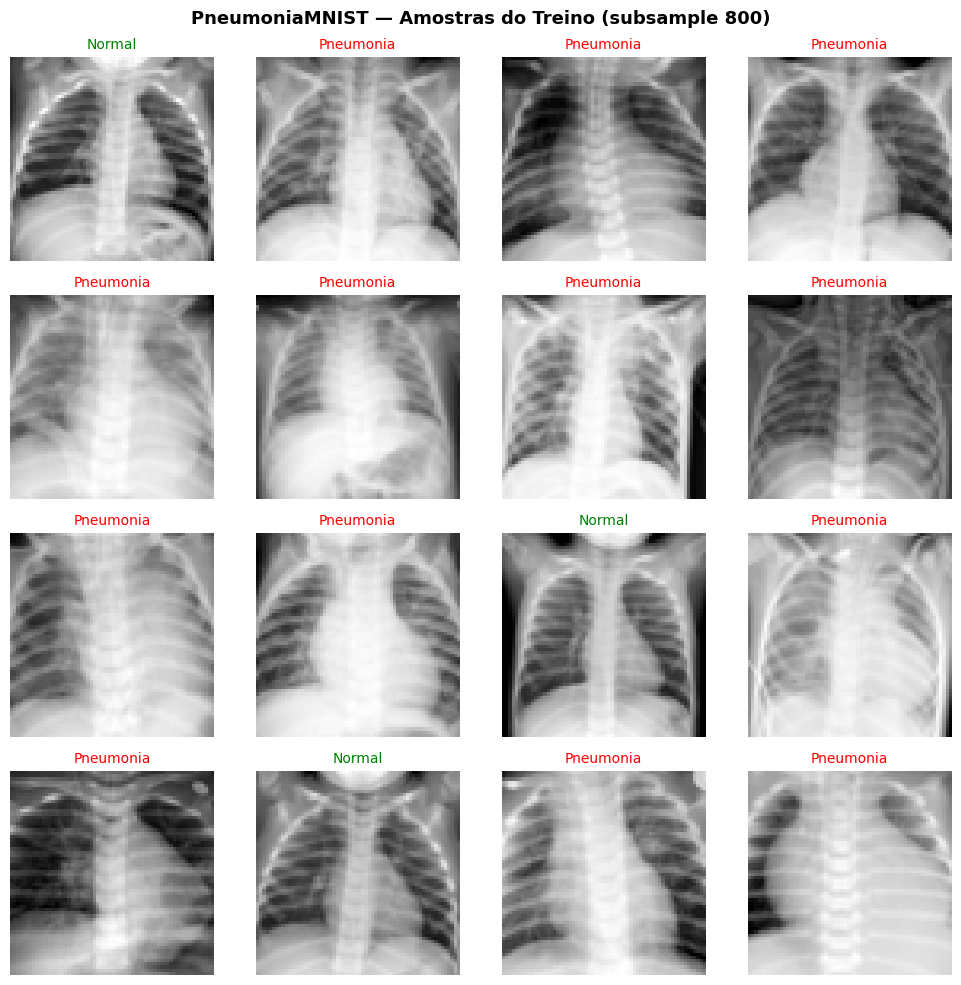

In [2]:
# GABARITO — Prompt Card 1: Carregar PneumoniaMNIST
train_ds = PneumoniaMNIST(split='train', download=True, size=64)
val_ds   = PneumoniaMNIST(split='val',   download=True, size=64)
test_ds  = PneumoniaMNIST(split='test',  download=True, size=64)

def preprocess(ds):
    imgs = ds.imgs.astype('float32') / 255.0
    if imgs.ndim == 3:
        imgs = imgs[..., np.newaxis]
    imgs   = np.repeat(imgs, 3, axis=-1)          # (N, 64, 64, 3)
    labels = ds.labels.flatten().astype('int')
    return imgs, labels

x_train, y_train = preprocess(train_ds)
x_val,   y_val   = preprocess(val_ds)
x_test,  y_test  = preprocess(test_ds)

# ── Subsample para 1000 imagens no total (~800 / 100 / 100) ───────────────────
rng_sub = np.random.default_rng(SEED)
for split, x_attr, y_attr, n in [
    ('x_train', x_train, y_train, 800),
    ('x_val',   x_val,   y_val,   100),
    ('x_test',  x_test,  y_test,  100),
]:
    idx = rng_sub.choice(len(x_attr), n, replace=False)
    if split == 'x_train': x_train, y_train = x_attr[idx], y_attr[idx]
    elif split == 'x_val': x_val,   y_val   = x_attr[idx], y_attr[idx]
    else:                  x_test,  y_test  = x_attr[idx], y_attr[idx]

class_names = ['Normal', 'Pneumonia']
for name, x, y in [('Treino', x_train, y_train), ('Validação', x_val, y_val), ('Teste', x_test, y_test)]:
    u, c = np.unique(y, return_counts=True)
    print(f'{name}: {x.shape} | {dict(zip([class_names[i] for i in u], c))}')

rng = np.random.default_rng(SEED)
idx = rng.choice(len(x_train), 16, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('PneumoniaMNIST — Amostras do Treino (subsample 800)', fontsize=13, fontweight='bold')
for ax, i in zip(axes.flat, idx):
    ax.imshow(x_train[i, :, :, 0], cmap='gray')
    ax.set_title(class_names[y_train[i]], color='red' if y_train[i]==1 else 'green', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 📦 Carregar e Visualizar o Dataset


In [ ]:
# ✦ Código gerado pelo Gemini (Prompt Card 1)

## 🎬 Extração de Embeddings + t-SNE

In [ ]:
# ✦ Código gerado pelo Gemini (Prompt Card 2)

In [3]:
# GABARITO — Prompt Card 2: Extração de Embeddings + t-SNE

# 1. Carregar o EfficientNetB0 pré-treinado no ImageNet
print('⏳ Baixando EfficientNetB0 pré-treinado no ImageNet (~21MB)...')
backbone = torchvision.models.efficientnet_b0(weights='IMAGENET1K_V1')
# Congelar todos os parâmetros do backbone
for param in backbone.parameters():
    param.requires_grad = False

# Criar um extrator de características do EfficientNetB0
extrator_effnet = nn.Sequential(
    backbone.features,
    backbone.avgpool,
    nn.Flatten()
).to(DEVICE)
print('✅ EfficientNetB0 carregado e congelado!')

# 2. Extrair embeddings para todo o dataset de teste
print('⏳ Extraindo embeddings com EfficientNetB0 para o dataset de teste...')
emb_test_effnet = extrair_embeddings_cnn(extrator_effnet, x_test)
print(f'   Shape dos embeddings do EfficientNetB0: {emb_test_effnet.shape}')

# 3. Carregar o RAD-DINO pré-treinado em radiologia
print('⏳ Baixando RAD-DINO da Microsoft (~87MB)...')
extrator_raddino  = AutoModel.from_pretrained('microsoft/rad-dino')
processor_raddino = AutoImageProcessor.from_pretrained('microsoft/rad-dino')
# Congelar todos os parâmetros do extrator
for param in extrator_raddino.parameters():
    param.requires_grad = False
extrator_raddino = extrator_raddino.to(DEVICE)
print('✅ RAD-DINO carregado e congelado!')

# Converter imagens de teste para formato PIL para o RAD-DINO
imgs_pil_test = numpy_to_pil(x_test)

# 4. Extrair embeddings com RAD-DINO para todo o dataset de teste
print('⏳ Extraindo embeddings com RAD-DINO para o dataset de teste (CLS token, ~15s)...')
emb_test_raddino = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_test)
print(f'   Shape dos embeddings do RAD-DINO: {emb_test_raddino.shape}')

# 5. Concatenar embeddings e rodar t-SNE
print('⏳ Rodando t-SNE para visualizar os embeddings...')
# Combinar os embeddings para t-SNE (limitando a amostras para visualização se necessário)
# Para este exemplo, vamos usar os embeddings de teste
all_embeddings = np.vstack((emb_test_effnet, emb_test_raddino))
all_labels = np.hstack((y_test, y_test)) # Labels são os mesmos para ambos os conjuntos

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Separar os embeddings 2D de volta para EfficientNet e RAD-DINO
emb_effnet_2d = embeddings_2d[:len(emb_test_effnet)]
emb_raddino_2d = embeddings_2d[len(emb_test_effnet):]

# 6. Plotar resultados do t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Visualização t-SNE dos Embeddings de Teste', fontsize=16, fontweight='bold')

# Plot EfficientNetB0
sns.scatterplot(
    x=emb_effnet_2d[:, 0], y=emb_effnet_2d[:, 1],
    hue=all_labels[:len(emb_test_effnet)], palette='viridis', legend='full', ax=axes[0]
)
axes[0].set_title('EfficientNetB0 (ImageNet)')
axes[0].set_xlabel('t-SNE Componente 1')
axes[0].set_ylabel('t-SNE Componente 2')
axes[0].legend(title='Classe', labels=['Normal', 'Pneumonia'])

# Plot RAD-DINO
sns.scatterplot(
    x=emb_raddino_2d[:, 0], y=emb_raddino_2d[:, 1],
    hue=all_labels[len(emb_test_effnet):], palette='viridis', legend='full', ax=axes[1]
)
axes[1].set_title('RAD-DINO (Radiologia)')
axes[1].set_xlabel('t-SNE Componente 1')
axes[1].set_ylabel('t-SNE Componente 2')
axes[1].legend(title='Classe', labels=['Normal', 'Pneumonia'])

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

⏳ Baixando EfficientNetB0 pré-treinado no ImageNet (~21MB)...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 66.8MB/s]


✅ EfficientNetB0 carregado e congelado!
⏳ Extraindo embeddings com EfficientNetB0 para o dataset de teste...
   Shape dos embeddings do EfficientNetB0: (100, 1280)
⏳ Baixando RAD-DINO da Microsoft (~87MB)...


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ RAD-DINO carregado e congelado!
⏳ Extraindo embeddings com RAD-DINO para o dataset de teste (CLS token, ~15s)...
   Shape dos embeddings do RAD-DINO: (100, 768)
⏳ Rodando t-SNE para visualizar os embeddings...


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1280 and the array at index 1 has size 768

## 🏗️ Classificador 1: EfficientNetB0 (ImageNet)

In [ ]:
# ✦ Código gerado pelo Gemini (Prompt Card 3)

⏳ Extraindo embeddings com EfficientNetB0 para treino e validação...
   Treino: (800, 1280) | Val: (100, 1280)
⏳ Treinando cabeça classificadora para EfficientNetB0...
✅ Treinamento da cabeça classificadora EfficientNetB0 concluído!


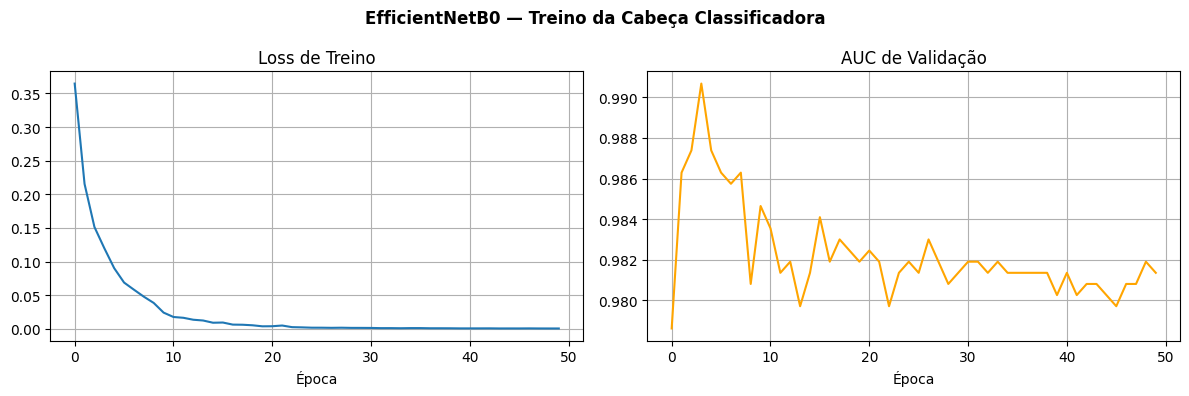


--- Avaliação: EfficientNetB0 (ImageNet) ---
Acurácia: 0.7700
AUC: 0.8797
Precisão: 0.7349
Recall: 0.9839
F1-Score: 0.8414
Matriz de Confusão:
[[16 22]
 [ 1 61]]


In [4]:
# GABARITO — Prompt Card 3: EfficientNetB0 (ImageNet)

# 1. Criar extrator congelado
# O extrator já foi criado e congelado na etapa anterior (Prompt Card 2)
# 'extrator_effnet' já está disponível.

# 2. Extrair embeddings para os datasets de treino e validação
# Embeddings de teste já foram extraídos na etapa anterior.
print('⏳ Extraindo embeddings com EfficientNetB0 para treino e validação...')
emb_train_effnet = extrair_embeddings_cnn(extrator_effnet, x_train)
emb_val_effnet   = extrair_embeddings_cnn(extrator_effnet, x_val)
print(f'   Treino: {emb_train_effnet.shape} | Val: {emb_val_effnet.shape}')

# 3. Treinar cabeça classificadora
print('⏳ Treinando cabeça classificadora para EfficientNetB0...')
head_effnet, hist_effnet = treinar_cabeca(
    emb_train_effnet, y_train, emb_val_effnet, y_val, in_features=1280
)
print('✅ Treinamento da cabeça classificadora EfficientNetB0 concluído!')

# 4. Plotar curvas de Loss e Val AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_effnet['loss'])
ax1.set_title('Loss de Treino')
ax1.set_xlabel('Época')
ax1.grid(True)

ax2.plot(hist_effnet['val_auc'], color='orange')
ax2.set_title('AUC de Validação')
ax2.set_xlabel('Época')
ax2.grid(True)
plt.suptitle('EfficientNetB0 — Treino da Cabeça Classificadora', fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Avaliar o modelo no conjunto de teste
resultados_effnet = avaliar(head_effnet, emb_test_effnet, y_test, 'EfficientNetB0 (ImageNet)')

## 🏗️ Classificador 2: RAD-DINO (Radiologia)

In [ ]:
# ✦ Código gerado pelo Gemini (Prompt Card 4)

⏳ Convertendo imagens de treino e validação para formato PIL...
✅ Conversão concluída!
⏳ Extraindo embeddings com RAD-DINO para treino e validação (CLS token, ~15s)...
   Treino: (800, 768) | Val: (100, 768)
⏳ Treinando cabeça classificadora para RAD-DINO...
✅ Treinamento da cabeça classificadora RAD-DINO concluído!


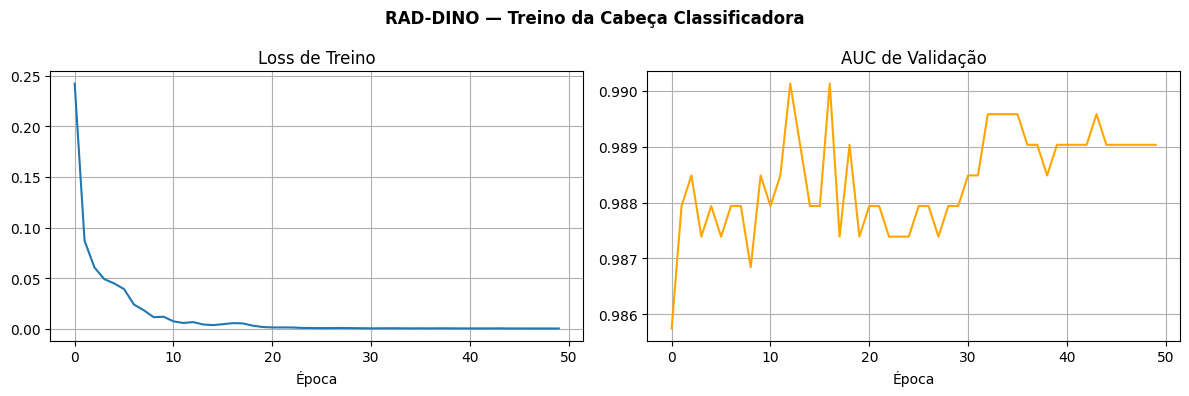


--- Avaliação: RAD-DINO (Radiologia) ---
Acurácia: 0.9500
AUC: 0.9979
Precisão: 0.9254
Recall: 1.0000
F1-Score: 0.9612
Matriz de Confusão:
[[33  5]
 [ 0 62]]


In [5]:
# GABARITO — Classificador 2: RAD-DINO (Radiologia)

# 1. Carregar extrator congelado
# O extrator já foi criado e congelado na etapa anterior (Prompt Card 2)
# 'extrator_raddino' e 'processor_raddino' já estão disponíveis.

# 2. Converter imagens para PIL (treino e validação)
print('⏳ Convertendo imagens de treino e validação para formato PIL...')
imgs_pil_train = numpy_to_pil(x_train)
imgs_pil_val   = numpy_to_pil(x_val)
print('✅ Conversão concluída!')

# 3. Extrair embeddings para os datasets de treino e validação
# Embeddings de teste já foram extraídos na etapa anterior.
print('⏳ Extraindo embeddings com RAD-DINO para treino e validação (CLS token, ~15s)...')
emb_train_raddino = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_train)
emb_val_raddino   = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_val)
print(f'   Treino: {emb_train_raddino.shape} | Val: {emb_val_raddino.shape}')

# 4. Treinar cabeça classificadora
print('⏳ Treinando cabeça classificadora para RAD-DINO...')
head_raddino, hist_raddino = treinar_cabeca(
    emb_train_raddino, y_train, emb_val_raddino, y_val, in_features=768
)
print('✅ Treinamento da cabeça classificadora RAD-DINO concluído!')

# 5. Plotar curvas de Loss e Val AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_raddino['loss'])
ax1.set_title('Loss de Treino')
ax1.set_xlabel('Época')
ax1.grid(True)

ax2.plot(hist_raddino['val_auc'], color='orange')
ax2.set_title('AUC de Validação')
ax2.set_xlabel('Época')
ax2.grid(True)
plt.suptitle('RAD-DINO — Treino da Cabeça Classificadora', fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Avaliar o modelo no conjunto de teste
resultados_raddino = avaliar(head_raddino, emb_test_raddino, y_test, 'RAD-DINO (Radiologia)')

## 📊 Comparação de Resultados

In [ ]:
# ✦ Código gerado pelo Gemini (Prompt Card 5)

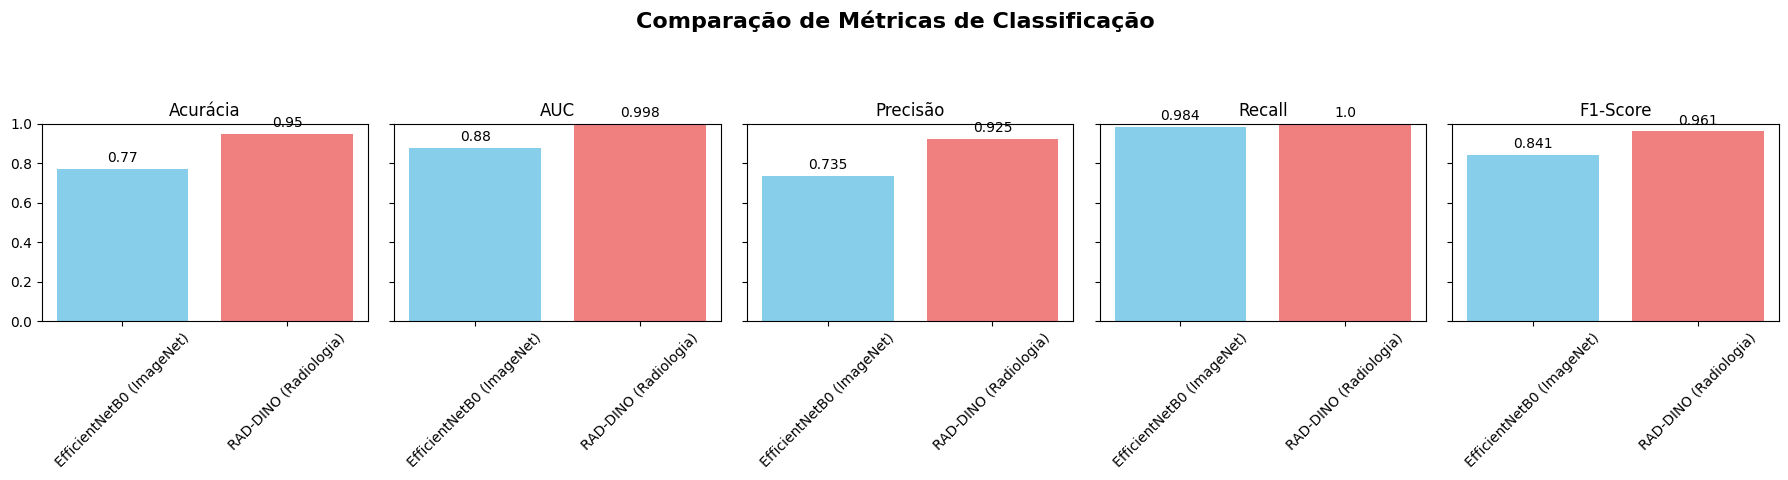

In [6]:
# GABARITO — Comparação de Resultados
# Plotar comparação de métricas entre os dois modelos
plotar_comparacao_metricas(resultados_effnet, resultados_raddino)

## 🔎 Inferência em Imagem Própria

In [ ]:
# ✦ Código gerado pelo Gemini (Prompt Card 6)

In [7]:
# GABARITO — Inferência em Imagem Própria
# Permite fazer upload de imagem e inferência com ambos os modelos

try:
    from google.colab import files
    import io

    print('Faça upload de uma imagem de raio-X de tórax:')
    uploaded = files.upload()

    for filename in uploaded.keys():
        # Carregar imagem
        img = Image.open(io.BytesIO(uploaded[filename]))
        img = img.convert('RGB').resize((64, 64))
        img_array = np.array(img).astype('float32') / 255.0

        # Inferência com EfficientNetB0
        emb_eff = extrair_embeddings_cnn(extrator_effnet, img_array[np.newaxis, :])
        prob_eff = torch.softmax(head_effnet(torch.from_numpy(emb_eff).float().to(DEVICE)), dim=1)[:, 1].item()
        pred_eff = 'Pneumonia' if prob_eff > 0.5 else 'Normal'

        # Inferência com RAD-DINO
        img_pil = Image.fromarray((img_array * 255).astype('uint8'))
        emb_rad = extrair_embeddings_raddino(extrator_raddino, processor_raddino, [img_pil])
        prob_rad = torch.softmax(head_raddino(torch.from_numpy(emb_rad).float().to(DEVICE)), dim=1)[:, 1].item()
        pred_rad = 'Pneumonia' if prob_rad > 0.5 else 'Normal'

        # Visualizar resultados
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(img, cmap='gray')
        axes[0].set_title('Imagem Original')
        axes[0].axis('off')

        axes[1].bar(['Normal', 'Pneumonia'], [1-prob_eff, prob_eff], color=['blue', 'red'], alpha=0.7)
        axes[1].set_title(f'EfficientNetB0: {pred_eff}')
        axes[1].set_ylim([0, 1])
        axes[1].set_ylabel('Probabilidade')

        axes[2].bar(['Normal', 'Pneumonia'], [1-prob_rad, prob_rad], color=['blue', 'red'], alpha=0.7)
        axes[2].set_title(f'RAD-DINO: {pred_rad}')
        axes[2].set_ylim([0, 1])
        axes[2].set_ylabel('Probabilidade')

        plt.tight_layout()
        plt.show()

except ImportError:
    print('Função de upload disponível apenas no Google Colab')

Faça upload de uma imagem de raio-X de tórax:


---
---
# 💬 Discussão Clínica

## O que aconteceu?

Ambos os backbones ficaram **completamente congelados** durante o experimento. Apenas a cabeça classificadora foi treinada — e era idêntica para os dois:

| | EfficientNetB0 | RAD-DINO |
|---|---|---|
| **Pré-treinamento** | ImageNet (1,28M fotos naturais) | 880K+ RX de tórax (MIMIC, CheXpert, NIH, PadChest, BRAX) |
| **Arquitetura** | CNN (EfficientNet) | ViT-B/14 com DINOv2 |
| **Dim. embedding** | 1.280 | 768 |
| **Parâmetros treinados** | ~262K (só head) | ~262K (só head) |
| **Tamanho do modelo** | ~21MB | ~87MB |

## Perguntas para reflexão

**1. Por que o t-SNE do RAD-DINO mostra clusters mais separados?**
> Os embeddings do RAD-DINO já codificam padrões clínicos radiológicos (opacidades, consolidações, textura pulmonar anormal). O EfficientNetB0 ImageNet codifica bordas e texturas de imagens naturais — parcialmente útil, mas sem especificidade clínica.

**2. Por que treinamos APENAS a cabeça (feature extraction)?**
> Fine-tuning completo com 5.856 imagens em um backbone de 86M+ parâmetros causaria overfitting severo. Feature extraction é a abordagem padrão quando o dataset clínico é pequeno.

**3. O RAD-DINO foi treinado em pneumonia especificamente?**
> Não. Foi treinado de forma auto-supervisionada (DINOv2) em raios-X gerais — sem labels de diagnóstico. A separação que vemos vem do conhecimento geral de radiologia de tórax aprendido de forma não-supervisionada.

**4. Isso é suficiente para uso clínico real?**
> Não. Imagens 64×64 perdem detalhes diagnósticos críticos. O dataset tem viés geográfico (crianças de Guangzhou). Sem validação prospectiva nem aprovação regulatória. Este é um experimento educacional para demonstrar o princípio da **transferência de domínio**.

**5. Qual é a implicação prática para radiologia?**
> Ao escolher um modelo pré-treinado para fine-tuning em uma tarefa radiológica, modelos treinados em dados clínicos radiológicos tendem a superar modelos de propósito geral — mesmo quando apenas a cabeça é treinada.

---

## Referências

- **PneumoniaMNIST:** Kermany DS et al., *Cell*, 2018. doi: 10.1016/j.cell.2018.02.010
- **RAD-DINO:** Pérez-García F et al., *Nature Machine Intelligence*, 2025. doi: 10.1038/s42256-024-00965-w
- **DINOv2:** Oquab M et al., *TMLR*, 2024. arXiv: 2304.07193
- **MedMNIST v2:** Yang J et al., *Scientific Data*, 2023. doi: 10.1038/s41597-022-01721-8
- **EfficientNet:** Tan M, Le QV, *ICML*, 2019. arXiv: 1905.11946


---
---
---
# 📚 GABARITO — Código de Referência (Apenas para o Instrutor)

> Implementação completa de referência para os 7 Prompt Cards.
> Use apenas se algum participante travar completamente.
> O objetivo é que todos construam via Gemini, não usando este código diretamente.


## 🔧 Setup e Preparação



In [ ]:
import warnings
warnings.filterwarnings('ignore') # Ignorar avisos do medmnist

# ── Instalações ───────────────────────────────────────────────────────────────
!pip install -qqq medmnist torchvision transformers accelerate scikit-learn matplotlib seaborn

# ── Imports ───────────────────────────────────────────────────────────────────
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import torchvision

from medmnist import PneumoniaMNIST

from transformers import AutoImageProcessor, AutoModel

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.manifold import TSNE

# ── Setup Básico ──────────────────────────────────────────────────────────────
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando device: {DEVICE}')

# ── Funções Auxiliares ────────────────────────────────────────────────────────

def numpy_to_pil(images_np):
    """Converte um array numpy de imagens (N, H, W, C) para uma lista de imagens PIL."""
    # Certifica-se de que a imagem esteja no formato (H, W, C) e tipo uint8
    # e que esteja no range [0, 255]
    images_np = (images_np * 255).astype(np.uint8)
    pil_images = [Image.fromarray(img[:,:,0] if img.shape[-1] == 1 else img) for img in images_np]
    return pil_images

def extrair_embeddings_cnn(model, images_np, batch_size=32):
    """Extrai embeddings de um modelo CNN (ex: EfficientNetB0)."""
    # O modelo espera 3 canais de entrada
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
    ])

    dataset = TensorDataset(torch.stack([transform(Image.fromarray((img * 255).astype(np.uint8))) for img in images_np]))
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    embeddings = []
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            img_batch = batch[0].to(DEVICE)
            emb = model(img_batch).cpu().numpy()
            embeddings.append(emb)
    return np.vstack(embeddings)

def extrair_embeddings_raddino(model, processor, images_pil, batch_size=32):
    """Extrai embeddings do modelo RAD-DINO."""
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(images_pil), batch_size):
            batch_pil = images_pil[i:i+batch_size]
            inputs = processor(images=batch_pil, return_tensors='pt').to(DEVICE)
            outputs = model(**inputs)
            # O RAD-DINO usa o CLS token como embedding global da imagem
            emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(emb)
    return np.vstack(embeddings)

class ClassificationHead(nn.Module):
    def __init__(self, in_features, num_classes=2, dropout_rate=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.head(x)

def treinar_cabeca(emb_train, y_train, emb_val, y_val, in_features, epochs=50, lr=1e-3, batch_size=32):
    """Treina a cabeça classificadora com os embeddings fornecidos."""
    set_seed(SEED) # Resetar seed para treinamento consistente

    head = ClassificationHead(in_features).to(DEVICE)
    optimizer = torch.optim.Adam(head.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_dataset = TensorDataset(torch.tensor(emb_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(torch.tensor(emb_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    history = {'loss': [], 'val_auc': []}

    for epoch in range(epochs):
        head.train()
        total_loss = 0
        for embeddings, labels in train_loader:
            embeddings, labels = embeddings.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = head(embeddings)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        history['loss'].append(total_loss / len(train_loader))

        head.eval()
        val_preds = []
        val_true = []
        val_probs = []
        with torch.no_grad():
            for embeddings, labels in val_loader:
                embeddings, labels = embeddings.to(DEVICE), labels.to(DEVICE)
                outputs = head(embeddings)
                val_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())
                val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        val_auc = roc_auc_score(val_true, val_probs)
        history['val_auc'].append(val_auc)

    return head, history

def avaliar(head, emb_test, y_test, model_name):
    """Avalia o modelo e imprime métricas."""
    head.eval()
    test_probs = []
    test_preds = []
    with torch.no_grad():
        embeddings_tensor = torch.tensor(emb_test, dtype=torch.float32).to(DEVICE)
        outputs = head(embeddings_tensor)
        test_probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        test_preds = torch.argmax(outputs, dim=1).cpu().numpy()

    accuracy  = accuracy_score(y_test, test_preds)
    auc       = roc_auc_score(y_test, test_probs)
    precision = precision_score(y_test, test_preds)
    recall    = recall_score(y_test, test_preds)
    f1        = f1_score(y_test, test_preds)
    cm        = confusion_matrix(y_test, test_preds)

    print(f'\n--- Avaliação: {model_name} ---')
    print(f'Acurácia: {accuracy:.4f}')
    print(f'AUC: {auc:.4f}')
    print(f'Precisão: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print(f'Matriz de Confusão:\n{cm}')

    return {'model_name': model_name, 'accuracy': accuracy, 'auc': auc, 'precision': precision, 'recall': recall, 'f1': f1}

def plotar_comparacao_metricas(res_effnet, res_raddino):
    """Plota a comparação das métricas entre os modelos."""
    metrics = ['accuracy', 'auc', 'precision', 'recall', 'f1']
    metric_names = ['Acurácia', 'AUC', 'Precisão', 'Recall', 'F1-Score']

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), sharey=True)
    fig.suptitle('Comparação de Métricas de Classificação', fontsize=16, fontweight='bold')

    for i, metric in enumerate(metrics):
        bars = axes[i].bar([res_effnet['model_name'], res_raddino['model_name']],
                           [res_effnet[metric], res_raddino[metric]],
                           color=['skyblue', 'lightcoral'])
        axes[i].set_title(metric_names[i])
        axes[i].set_ylim(0, 1) # Metrics are usually between 0 and 1
        axes[i].tick_params(axis='x', rotation=45)
        for bar in bars:
            yval = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2, yval + 0.02,
                         round(yval, 3), ha='center', va='bottom', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

## 📦 Carregar e Visualizar o Dataset


100%|██████████| 20.6M/20.6M [00:02<00:00, 9.95MB/s]


Treino: (800, 64, 64, 3) | {'Normal': np.int64(203), 'Pneumonia': np.int64(597)}
Validação: (100, 64, 64, 3) | {'Normal': np.int64(24), 'Pneumonia': np.int64(76)}
Teste: (100, 64, 64, 3) | {'Normal': np.int64(38), 'Pneumonia': np.int64(62)}


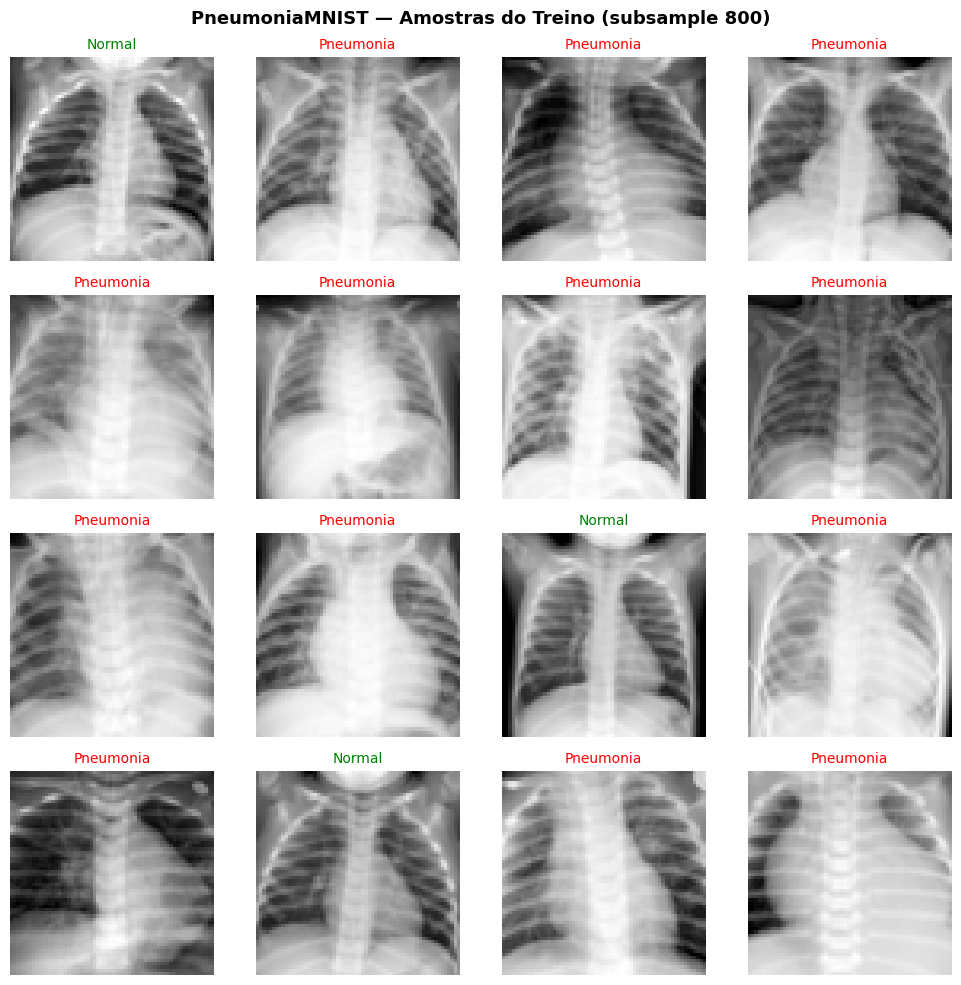

In [ ]:
# GABARITO — Prompt Card 1: Carregar PneumoniaMNIST
train_ds = PneumoniaMNIST(split='train', download=True, size=64)
val_ds   = PneumoniaMNIST(split='val',   download=True, size=64)
test_ds  = PneumoniaMNIST(split='test',  download=True, size=64)

def preprocess(ds):
    imgs = ds.imgs.astype('float32') / 255.0
    if imgs.ndim == 3:
        imgs = imgs[..., np.newaxis]
    imgs   = np.repeat(imgs, 3, axis=-1)          # (N, 64, 64, 3)
    labels = ds.labels.flatten().astype('int')
    return imgs, labels

x_train, y_train = preprocess(train_ds)
x_val,   y_val   = preprocess(val_ds)
x_test,  y_test  = preprocess(test_ds)

# ── Subsample para 1000 imagens no total (~800 / 100 / 100) ───────────────────
rng_sub = np.random.default_rng(SEED)
for split, x_attr, y_attr, n in [
    ('x_train', x_train, y_train, 800),
    ('x_val',   x_val,   y_val,   100),
    ('x_test',  x_test,  y_test,  100),
]:
    idx = rng_sub.choice(len(x_attr), n, replace=False)
    if split == 'x_train': x_train, y_train = x_attr[idx], y_attr[idx]
    elif split == 'x_val': x_val,   y_val   = x_attr[idx], y_attr[idx]
    else:                  x_test,  y_test  = x_attr[idx], y_attr[idx]

class_names = ['Normal', 'Pneumonia']
for name, x, y in [('Treino', x_train, y_train), ('Validação', x_val, y_val), ('Teste', x_test, y_test)]:
    u, c = np.unique(y, return_counts=True)
    print(f'{name}: {x.shape} | {dict(zip([class_names[i] for i in u], c))}')

rng = np.random.default_rng(SEED)
idx = rng.choice(len(x_train), 16, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('PneumoniaMNIST — Amostras do Treino (subsample 800)', fontsize=13, fontweight='bold')
for ax, i in zip(axes.flat, idx):
    ax.imshow(x_train[i, :, :, 0], cmap='gray')
    ax.set_title(class_names[y_train[i]], color='red' if y_train[i]==1 else 'green', fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 🎬 Extração de Embeddings + t-SNE

In [ ]:
# GABARITO — Prompt Card 2: Extração de Embeddings + t-SNE

# 1. Carregar o EfficientNetB0 pré-treinado no ImageNet
print('⏳ Baixando EfficientNetB0 pré-treinado no ImageNet (~21MB)...')
backbone = torchvision.models.efficientnet_b0(weights='IMAGENET1K_V1')
# Congelar todos os parâmetros do backbone
for param in backbone.parameters():
    param.requires_grad = False

# Criar um extrator de características do EfficientNetB0
extrator_effnet = nn.Sequential(
    backbone.features,
    backbone.avgpool,
    nn.Flatten()
).to(DEVICE)
print('✅ EfficientNetB0 carregado e congelado!')

# 2. Extrair embeddings para todo o dataset de teste
print('⏳ Extraindo embeddings com EfficientNetB0 para o dataset de teste...')
emb_test_effnet = extrair_embeddings_cnn(extrator_effnet, x_test)
print(f'   Shape dos embeddings do EfficientNetB0: {emb_test_effnet.shape}')

# 3. Carregar o RAD-DINO pré-treinado em radiologia
print('⏳ Baixando RAD-DINO da Microsoft (~87MB)...')
extrator_raddino  = AutoModel.from_pretrained('microsoft/rad-dino')
processor_raddino = AutoImageProcessor.from_pretrained('microsoft/rad-dino')
# Congelar todos os parâmetros do extrator
for param in extrator_raddino.parameters():
    param.requires_grad = False
extrator_raddino = extrator_raddino.to(DEVICE)
print('✅ RAD-DINO carregado e congelado!')

# Converter imagens de teste para formato PIL para o RAD-DINO
imgs_pil_test = numpy_to_pil(x_test)

# 4. Extrair embeddings com RAD-DINO para todo o dataset de teste
print('⏳ Extraindo embeddings com RAD-DINO para o dataset de teste (CLS token, ~15s)...')
emb_test_raddino = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_test)
print(f'   Shape dos embeddings do RAD-DINO: {emb_test_raddino.shape}')

# 5. Concatenar embeddings e rodar t-SNE
print('⏳ Rodando t-SNE para visualizar os embeddings...')
# Combinar os embeddings para t-SNE (limitando a amostras para visualização se necessário)
# Para este exemplo, vamos usar os embeddings de teste
all_embeddings = np.vstack((emb_test_effnet, emb_test_raddino))
all_labels = np.hstack((y_test, y_test)) # Labels são os mesmos para ambos os conjuntos

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Separar os embeddings 2D de volta para EfficientNet e RAD-DINO
emb_effnet_2d = embeddings_2d[:len(emb_test_effnet)]
emb_raddino_2d = embeddings_2d[len(emb_test_effnet):]

# 6. Plotar resultados do t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Visualização t-SNE dos Embeddings de Teste', fontsize=16, fontweight='bold')

# Plot EfficientNetB0
sns.scatterplot(
    x=emb_effnet_2d[:, 0], y=emb_effnet_2d[:, 1],
    hue=all_labels[:len(emb_test_effnet)], palette='viridis', legend='full', ax=axes[0]
)
axes[0].set_title('EfficientNetB0 (ImageNet)')
axes[0].set_xlabel('t-SNE Componente 1')
axes[0].set_ylabel('t-SNE Componente 2')
axes[0].legend(title='Classe', labels=['Normal', 'Pneumonia'])

# Plot RAD-DINO
sns.scatterplot(
    x=emb_raddino_2d[:, 0], y=emb_raddino_2d[:, 1],
    hue=all_labels[len(emb_test_effnet):], palette='viridis', legend='full', ax=axes[1]
)
axes[1].set_title('RAD-DINO (Radiologia)')
axes[1].set_xlabel('t-SNE Componente 1')
axes[1].set_ylabel('t-SNE Componente 2')
axes[1].legend(title='Classe', labels=['Normal', 'Pneumonia'])

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

⏳ Baixando EfficientNetB0 pré-treinado no ImageNet (~21MB)...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 66.8MB/s]


✅ EfficientNetB0 carregado e congelado!
⏳ Extraindo embeddings com EfficientNetB0 para o dataset de teste...
   Shape dos embeddings do EfficientNetB0: (100, 1280)
⏳ Baixando RAD-DINO da Microsoft (~87MB)...


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ RAD-DINO carregado e congelado!
⏳ Extraindo embeddings com RAD-DINO para o dataset de teste (CLS token, ~15s)...
   Shape dos embeddings do RAD-DINO: (100, 768)
⏳ Rodando t-SNE para visualizar os embeddings...


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1280 and the array at index 1 has size 768

## 🏗️ Classificador 1: EfficientNetB0 (ImageNet)

⏳ Extraindo embeddings com EfficientNetB0 para treino e validação...
   Treino: (800, 1280) | Val: (100, 1280)
⏳ Treinando cabeça classificadora para EfficientNetB0...
✅ Treinamento da cabeça classificadora EfficientNetB0 concluído!


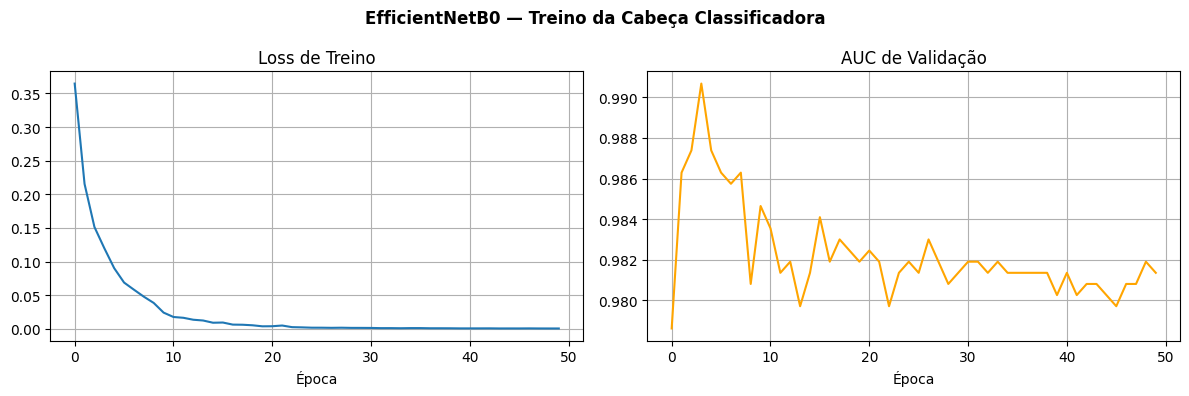


--- Avaliação: EfficientNetB0 (ImageNet) ---
Acurácia: 0.7700
AUC: 0.8797
Precisão: 0.7349
Recall: 0.9839
F1-Score: 0.8414
Matriz de Confusão:
[[16 22]
 [ 1 61]]


In [ ]:
# GABARITO — Prompt Card 3: EfficientNetB0 (ImageNet)

# 1. Criar extrator congelado
# O extrator já foi criado e congelado na etapa anterior (Prompt Card 2)
# 'extrator_effnet' já está disponível.

# 2. Extrair embeddings para os datasets de treino e validação
# Embeddings de teste já foram extraídos na etapa anterior.
print('⏳ Extraindo embeddings com EfficientNetB0 para treino e validação...')
emb_train_effnet = extrair_embeddings_cnn(extrator_effnet, x_train)
emb_val_effnet   = extrair_embeddings_cnn(extrator_effnet, x_val)
print(f'   Treino: {emb_train_effnet.shape} | Val: {emb_val_effnet.shape}')

# 3. Treinar cabeça classificadora
print('⏳ Treinando cabeça classificadora para EfficientNetB0...')
head_effnet, hist_effnet = treinar_cabeca(
    emb_train_effnet, y_train, emb_val_effnet, y_val, in_features=1280
)
print('✅ Treinamento da cabeça classificadora EfficientNetB0 concluído!')

# 4. Plotar curvas de Loss e Val AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_effnet['loss'])
ax1.set_title('Loss de Treino')
ax1.set_xlabel('Época')
ax1.grid(True)

ax2.plot(hist_effnet['val_auc'], color='orange')
ax2.set_title('AUC de Validação')
ax2.set_xlabel('Época')
ax2.grid(True)
plt.suptitle('EfficientNetB0 — Treino da Cabeça Classificadora', fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Avaliar o modelo no conjunto de teste
resultados_effnet = avaliar(head_effnet, emb_test_effnet, y_test, 'EfficientNetB0 (ImageNet)')

## 🏗️ Classificador 2: RAD-DINO (Radiologia)

⏳ Convertendo imagens de treino e validação para formato PIL...
✅ Conversão concluída!
⏳ Extraindo embeddings com RAD-DINO para treino e validação (CLS token, ~15s)...
   Treino: (800, 768) | Val: (100, 768)
⏳ Treinando cabeça classificadora para RAD-DINO...
✅ Treinamento da cabeça classificadora RAD-DINO concluído!


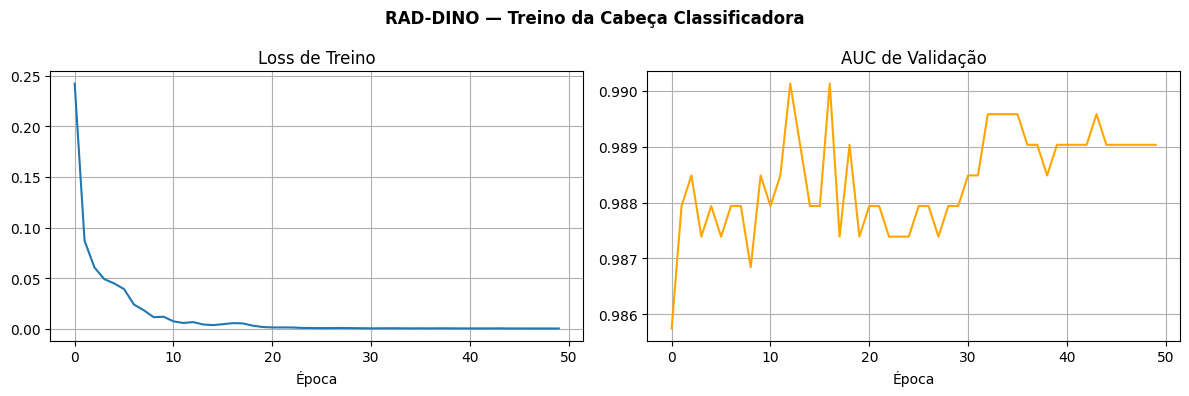


--- Avaliação: RAD-DINO (Radiologia) ---
Acurácia: 0.9500
AUC: 0.9979
Precisão: 0.9254
Recall: 1.0000
F1-Score: 0.9612
Matriz de Confusão:
[[33  5]
 [ 0 62]]


In [ ]:
# GABARITO — Classificador 2: RAD-DINO (Radiologia)

# 1. Carregar extrator congelado
# O extrator já foi criado e congelado na etapa anterior (Prompt Card 2)
# 'extrator_raddino' e 'processor_raddino' já estão disponíveis.

# 2. Converter imagens para PIL (treino e validação)
print('⏳ Convertendo imagens de treino e validação para formato PIL...')
imgs_pil_train = numpy_to_pil(x_train)
imgs_pil_val   = numpy_to_pil(x_val)
print('✅ Conversão concluída!')

# 3. Extrair embeddings para os datasets de treino e validação
# Embeddings de teste já foram extraídos na etapa anterior.
print('⏳ Extraindo embeddings com RAD-DINO para treino e validação (CLS token, ~15s)...')
emb_train_raddino = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_train)
emb_val_raddino   = extrair_embeddings_raddino(extrator_raddino, processor_raddino, imgs_pil_val)
print(f'   Treino: {emb_train_raddino.shape} | Val: {emb_val_raddino.shape}')

# 4. Treinar cabeça classificadora
print('⏳ Treinando cabeça classificadora para RAD-DINO...')
head_raddino, hist_raddino = treinar_cabeca(
    emb_train_raddino, y_train, emb_val_raddino, y_val, in_features=768
)
print('✅ Treinamento da cabeça classificadora RAD-DINO concluído!')

# 5. Plotar curvas de Loss e Val AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_raddino['loss'])
ax1.set_title('Loss de Treino')
ax1.set_xlabel('Época')
ax1.grid(True)

ax2.plot(hist_raddino['val_auc'], color='orange')
ax2.set_title('AUC de Validação')
ax2.set_xlabel('Época')
ax2.grid(True)
plt.suptitle('RAD-DINO — Treino da Cabeça Classificadora', fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Avaliar o modelo no conjunto de teste
resultados_raddino = avaliar(head_raddino, emb_test_raddino, y_test, 'RAD-DINO (Radiologia)')